In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
import copy
import seaborn as sns
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset, ConcatDataset

#import umap
#import hdbscan
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split, KFold
from sklearn.metrics import adjusted_rand_score
from tqdm import tqdm
from sklearn.manifold import TSNE

In [2]:
def read_unequal_table(txt_file, num_columns=383, filler=''):
    """Read table from file."""
    table = []
    with open(txt_file) as file:
        for row in file:
            values = row.split()
            if len(values) > num_columns:
                raise ValueError('Number of values more than num_columns')
            elif len(values) < num_columns:
                diff = num_columns - len(values)
                padding = [filler]*diff
                values = values + padding
            else:
                pass
            table.append(values)
    return np.array(table)

In [3]:
def read_norm_spectra(txt_file):
    """Read the saved set of normalized spectra"""
    alldata = read_unequal_table(txt_file)
    srcids = alldata[:, 0].astype(str)
    normed_spectra = alldata[:, 1:-2].astype(float)
    netcounts = alldata[:, -2].astype(float)
    src_class = alldata[:, -1].astype(str)
    return srcids, normed_spectra, netcounts, src_class

In [4]:
def refine_labels(label_array):
    """Refine labels to 4 classes."""
    refined_labels = np.full(len(label_array), '', dtype='<U16')
    for i, label in enumerate(label_array):
        if label == '':
            continue
        if label == 'AGN' or label == 'CV':
            refined_labels[i] = label
        elif label == 'LM-STAR' or label == 'HM-STAR' or label == 'YSO':
            refined_labels[i] = 'STAR'
        else:
            refined_labels[i] = 'NS/BH'
    return refined_labels

In [5]:
pn_srcids, pn_normspec, pn_counts, pn_class = read_norm_spectra('../Data/Brightmos_id_normspec_counts_label.txt')

In [6]:
allpn_srcids, allpn_normspec, allpn_counts, allpn_class = read_norm_spectra(
    '../Data/Allmos_id_normspec_counts_label.txt')

In [7]:
pn_class_refined = refine_labels(pn_class)

In [8]:
def check_spectra(normspec, refinedclass):
    """Check the normalized spectra of different classes."""
    en_bins = np.linspace(0.5, 10, len(normspec[0]))
    classes_unique = np.unique(refinedclass)
    #plt.figure(figsize=(20, 12))
    plt.xlabel('Energy [keV]')
    plt.ylabel('Normalized counts [/bin]')
    plt.xscale('log')
    plt.xlim(0.5, 10.0)
    for classes in classes_unique:
        if classes != '':
            plt.plot(en_bins,
                     np.mean(normspec[refinedclass == classes], axis=0), label=classes)
    plt.legend()
    plt.show

In [9]:
print(f"Number of AGN: {len(np.where(pn_class_refined == 'AGN')[0])}")
print(f"Number of STAR: {len(np.where(pn_class_refined == 'STAR')[0])}")
print(f"Number of NS: {len(np.where(pn_class_refined == 'NS/BH')[0])}")
print(f"Number of CVs: {len(np.where(pn_class_refined == 'CV')[0])}")

Number of AGN: 720
Number of STAR: 621
Number of NS: 81
Number of CVs: 81


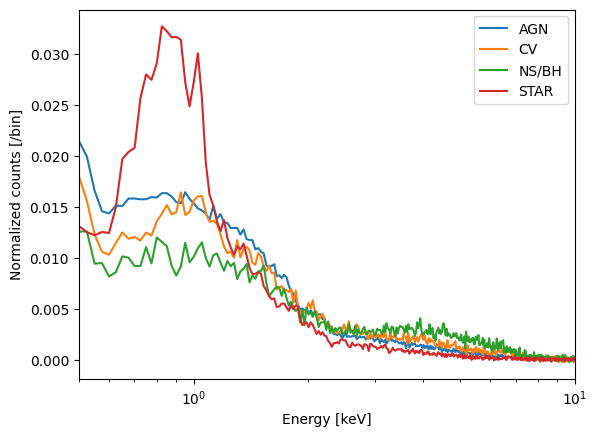

In [10]:
check_spectra(pn_normspec, pn_class_refined)

In [11]:
plt.rcParams.update({
    # Figure size
    "figure.figsize": (8, 6),

    # Ticks on all sides
    "xtick.top": True,
    "xtick.bottom": True,
    "ytick.left": True,
    "ytick.right": True,

    # Major and minor ticks visibility
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Tick direction and size
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,

    # Tick width
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # Grid for major ticks
    "axes.grid": False,
    #"grid.which": "major",
    #"grid.linestyle": "--",
    #"grid.color": "gray",
    #"grid.alpha": 0.5,

    # Font sizes for labels and ticks
    "axes.labelsize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
})

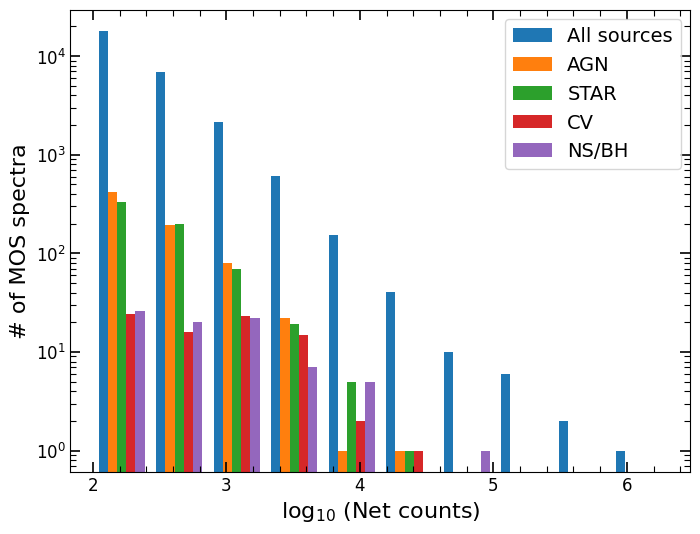

In [12]:
plt.hist([np.log10(pn_counts), np.log10(pn_counts[pn_class_refined=='AGN']),
          np.log10(pn_counts[pn_class_refined=='STAR']),
          np.log10(pn_counts[pn_class_refined=='CV']),
          np.log10(pn_counts[pn_class_refined=='NS/BH'])])
plt.yscale('log')
plt.xlabel(r'log$_{10}$ (Net counts)')
plt.ylabel('# of MOS spectra')
plt.legend(['All sources', 'AGN', 'STAR', 'CV', 'NS/BH'])

In [13]:
pn_srcid_bgcounts = np.loadtxt('../Data/MOS_bg_counts.txt')
pn_bgcounts = pn_srcid_bgcounts[:, 1]

In [14]:
pn_bg_ratio = (pn_bgcounts[allpn_counts >= 100]/pn_counts)

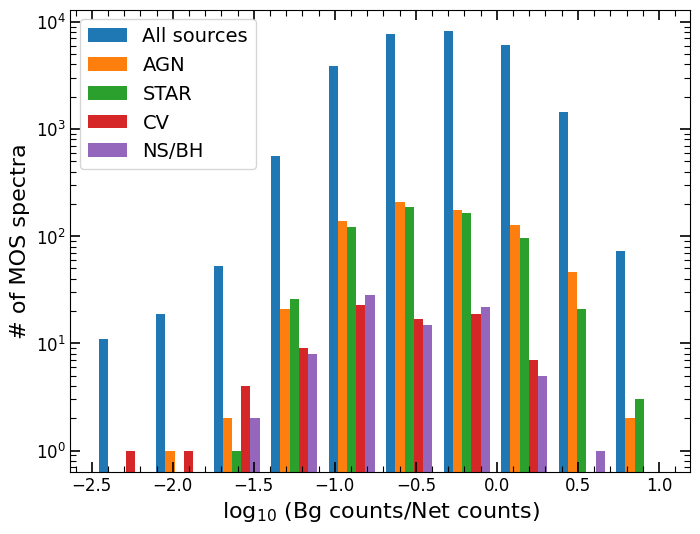

In [15]:
plt.hist([np.log10(pn_bg_ratio), np.log10(pn_bg_ratio[pn_class_refined=='AGN']),
          np.log10(pn_bg_ratio[pn_class_refined=='STAR']),
          np.log10(pn_bg_ratio[pn_class_refined=='CV']),
          np.log10(pn_bg_ratio[pn_class_refined=='NS/BH'])])
plt.yscale('log')
plt.xlabel(r'log$_{10}$ (Bg counts/Net counts)')
plt.ylabel('# of MOS spectra')
plt.legend(['All sources', 'AGN', 'STAR', 'CV', 'NS/BH'])

In [16]:
pn_labelled_normspecs = pn_normspec[
    np.where(np.logical_or(pn_class_refined == 'STAR',
                           pn_class_refined == 'AGN'))]
pn_labelled_counts = pn_counts[
    np.where(np.logical_or(pn_class_refined == 'STAR',
                           pn_class_refined == 'AGN'))]
pn_labelled_bgratio = pn_bg_ratio[
    np.where(np.logical_or(pn_class_refined == 'STAR',
                           pn_class_refined == 'AGN'))]

In [17]:
pn_labelled_normspecs.shape

(1341, 380)

# Analysis for Pseudolabelling

In [21]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=8, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(8)
        self.pool1 = nn.MaxPool1d(2)  # 380 → 190
        self.drop1 = nn.Dropout(dropout_rate)  # <-- dropout after first conv block

        self.conv2 = nn.Conv1d(8, 16, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(16)
        self.pool2 = nn.MaxPool1d(2)  # 190 → 95
        self.drop2 = nn.Dropout(dropout_rate)  # <-- dropout after second conv block

        # final feature size = 16 * 95 = 1520
        self.fc1 = nn.Linear(16 * 95, 64)
        self.drop3 = nn.Dropout(dropout_rate)  # <-- dropout before final layer
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.drop1(x)
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.drop2(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.drop3(x)
        return self.fc2(x)

NameError: name 'nn' is not defined

In [24]:
# load model and test data
model = torch.load('SimpleCNN_withreg_MOS.pt', weights_only=False)
test_ds = torch.load('test_data_mos.pt', weights_only=False)
base_dataset, base_labels = test_ds.dataset.tensors
base_indices = test_ds.indices
test_data, test_labels  = base_dataset[base_indices], base_labels[base_indices]
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_counts = pn_labelled_counts[base_indices]
test_labels = np.array(test_labels)

/var/folders/v5/192l36gj409197xbd3ttmt6c0000gt/T/ipykernel_73181/2856360283.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  test_labels = np.array(test_labels)


In [29]:
def evaluate(model, loader, device):
    model.eval()
    all_preds = np.array([])
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = list(np.array(model(xb).argmax(dim=1)))
            all_preds = np.append(all_preds.copy(), preds)
            
    return all_preds

## Performance evaluation

In [131]:
def get_stats(preds, labels, conf=None, threshold=0.9):
    if conf is None:
        conf = np.ones(len(preds), dtype=bool)
    preds0 = np.logical_and(preds == 0, conf >= threshold).sum()
    preds1 = np.logical_and(preds == 1, conf >= threshold).sum()
    labels0 = (labels == 0).sum()
    labels1 = (labels == 1).sum()
    corr0 = np.logical_and(np.logical_and(preds==0, labels==0),
                           conf >= threshold).sum()
    corr1 = np.logical_and(np.logical_and(preds==1, labels==1),
                           conf >= threshold).sum()
    return ((corr0 + corr1)/len(preds[conf>=threshold]),
            corr0/labels0, corr1/labels1,
            corr0/preds0, corr1/preds1)

In [31]:
def get_binned_stats(preds, labels, counts, count_bins=None):
    if count_bins is None:
        count_bins = np.logspace(np.log10(np.min(counts)),
                                 np.log10(np.max(counts)), 11)
    acc_arr = np.zeros(len(count_bins)-1, dtype=float)
    tnr_arr = np.zeros(len(count_bins)-1, dtype=float)
    rec_arr = np.zeros(len(count_bins)-1, dtype=float)
    npv_arr = np.zeros(len(count_bins)-1, dtype=float)
    prec_arr = np.zeros(len(count_bins)-1, dtype=float)
    for i, min_count in enumerate(count_bins[:-1]):
        bin_args = np.where(
            np.logical_and(counts >= min_count, counts < count_bins[i+1]))[0]
        (acc_arr[i], tnr_arr[i], rec_arr[i],
         npv_arr[i], prec_arr[i]) = get_stats(preds[bin_args],
                                              labels[bin_args])
    return (count_bins, acc_arr, tnr_arr, rec_arr, npv_arr, prec_arr)

In [96]:
def plot_hist_stats(counts, counts0, counts1, count_bins, acc_arr, rec_arr,
                    tnr_arr, prec_arr, npv_arr, prop_name):
    fig, ax1 = plt.subplots()
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel(prop_name)
    ax1.set_ylabel('# per bin')
    ax1.hist([counts, counts0, counts1], bins=count_bins,
             color=colors_light,
             label=['All', 'AGN', 'STAR'])
    ax1.legend()
    ax1.minorticks_on()

    ax2 = ax1.twinx()
    ax2.set_ylabel('Model performance')
    bincounts_mid = 0.5*(count_bins[:-1] + count_bins[1:])
    ax2.plot(bincounts_mid, acc_arr, label='Accuracy', color=colors_bright[0],
             linestyle='-')
    ax2.plot(bincounts_mid, rec_arr, label='Recall', color=colors_bright[1],
             linestyle='--')
    ax2.plot(bincounts_mid, tnr_arr, label='TNR', color=colors_bright[2],
             linestyle='--')
    ax2.plot(bincounts_mid, prec_arr, label='Precision', color=colors_bright[3],
             linestyle='-.')
    ax2.plot(bincounts_mid, npv_arr, label='NPV', color=colors_bright[4],
             linestyle='-.')
    ax2.set_ylim(0.5, 1.005)
    ax2.legend(loc='lower left')
    ax2.minorticks_on()

In [85]:
def plot_model_perf(model, loader, labels, prop, prop_name):
    """Plot model performance"""
    preds = evaluate_auto(model, loader, device)
    print(get_stats(preds, labels))
    (prop_bins, acc_arr, tnr_arr,
     rec_arr, npv_arr, prec_arr) = get_binned_stats(
        preds, labels, prop)
    agn_prop = prop[labels==0]
    star_prop = prop[labels==1]
    plot_hist_stats(prop, agn_prop, star_prop, prop_bins, acc_arr,
                    rec_arr, tnr_arr, prec_arr, npv_arr, prop_name)
    return (prop_bins, acc_arr, tnr_arr, rec_arr, npv_arr, prec_arr)

In [34]:
colors_light = ['#6699cc', '#ee99aa', '#eecc66']
colors_bright = ['#000000', '#004488', '#882255', '#117733', '#ee7733']

### No pseudolabel

In [35]:
test_bgratio = pn_labelled_bgratio[base_indices]

(0.929368029739777, 0.9027777777777778, 0.96, 0.9629629629629629, 0.8955223880597015)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in long_scalars
  
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == '__main__':


(array([  100.08875257,   164.36050482,   269.90420852,   443.22254825,
          727.83684386,  1195.21552632,  1962.72030799,  3223.07644318,
         5292.7672457 ,  8691.50502974, 14272.73412473]),
 array([0.87671233, 0.94252874, 0.92105263, 0.94117647, 1.        ,
        1.        , 1.        , 1.        ,        nan,        nan]),
 array([0.82978723, 0.94871795, 0.86363636, 0.94444444, 1.        ,
        1.        , 1.        ,        nan,        nan,        nan]),
 array([0.96153846, 0.9375    , 1.        , 0.9375    , 1.        ,
        1.        , 1.        , 1.        ,        nan,        nan]),
 array([0.975     , 0.925     , 1.        , 0.94444444, 1.        ,
        1.        , 1.        ,        nan,        nan,        nan]),
 array([0.75757576, 0.95744681, 0.84210526, 0.9375    , 1.        ,
        1.        , 1.        , 1.        ,        nan,        nan]))

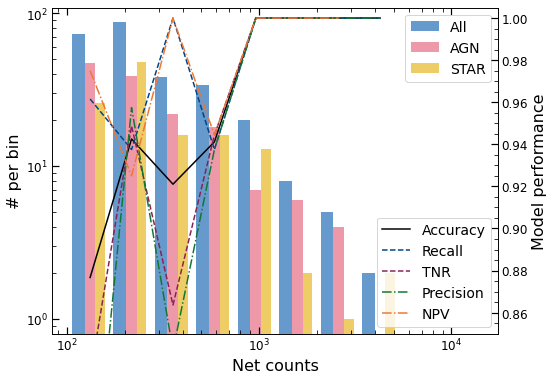

In [40]:
plot_model_perf(model, test_loader, test_labels, test_counts, 'Net counts')

(0.929368029739777, 0.9027777777777778, 0.96, 0.9629629629629629, 0.8955223880597015)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in long_scalars
  
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == '__main__':


(array([0.04110063, 0.06798623, 0.11245881, 0.18602273, 0.30770783,
        0.50899214, 0.84194476, 1.39269535, 2.30371449, 3.81066859,
        6.30338316]),
 array([1.        , 1.        , 0.97674419, 0.95555556, 0.95652174,
        0.91836735, 0.88571429, 0.91666667, 0.8       , 0.66666667]),
 array([       nan, 1.        , 0.95652174, 0.9       , 0.92307692,
        0.92      , 0.81818182, 0.93333333, 0.85714286, 0.5       ]),
 array([1.        , 1.        , 1.        , 1.        , 1.        ,
        0.91666667, 1.        , 0.88888889, 0.66666667, 1.        ]),
 array([       nan, 1.        , 1.        , 1.        , 1.        ,
        0.92      , 1.        , 0.93333333, 0.85714286, 1.        ]),
 array([1.        , 1.        , 0.95238095, 0.92592593, 0.90909091,
        0.91666667, 0.76470588, 0.88888889, 0.66666667, 0.5       ]))

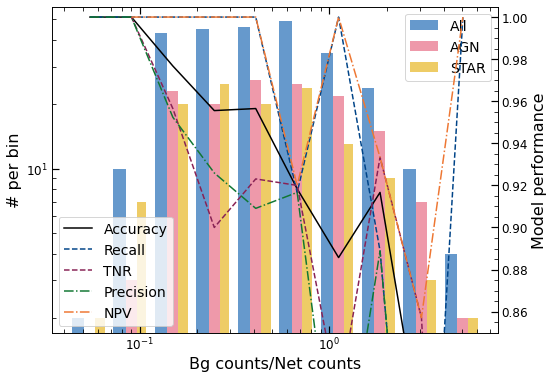

In [42]:
plot_model_perf(model, test_loader, test_labels, test_bgratio,
                'Bg counts/Net counts')

### With Pseudolabel

In [25]:
model_pl = torch.load('SimpleCNN_reg_leePsuedolabel_MOS.pt', weights_only=False)

(0.9219330855018587, 0.9652777777777778, 0.872, 0.896774193548387, 0.956140350877193)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in long_scalars
  
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == '__main__':


(array([  100.08875257,   164.36050482,   269.90420852,   443.22254825,
          727.83684386,  1195.21552632,  1962.72030799,  3223.07644318,
         5292.7672457 ,  8691.50502974, 14272.73412473]),
 array([0.91780822, 0.87356322, 0.97368421, 0.94117647, 0.95      ,
        1.        , 1.        , 1.        ,        nan,        nan]),
 array([0.93617021, 0.97435897, 1.        , 0.94444444, 1.        ,
        1.        , 1.        ,        nan,        nan,        nan]),
 array([0.88461538, 0.79166667, 0.9375    , 0.9375    , 0.92307692,
        1.        , 1.        , 1.        ,        nan,        nan]),
 array([0.93617021, 0.79166667, 0.95652174, 0.94444444, 0.875     ,
        1.        , 1.        ,        nan,        nan,        nan]),
 array([0.88461538, 0.97435897, 1.        , 0.9375    , 1.        ,
        1.        , 1.        , 1.        ,        nan,        nan]))

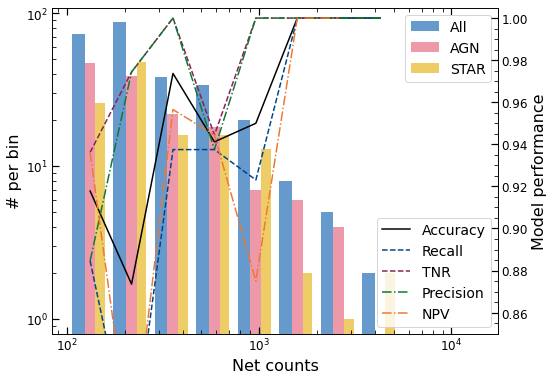

In [46]:
plot_model_perf(model_pl, test_loader, test_labels, test_counts, 'Net counts')

(0.9219330855018587, 0.9652777777777778, 0.872, 0.896774193548387, 0.956140350877193)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in long_scalars
  
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == '__main__':


(array([0.04110063, 0.06798623, 0.11245881, 0.18602273, 0.30770783,
        0.50899214, 0.84194476, 1.39269535, 2.30371449, 3.81066859,
        6.30338316]),
 array([1.        , 1.        , 0.97674419, 0.95555556, 0.95652174,
        0.85714286, 0.91428571, 0.83333333, 0.9       , 1.        ]),
 array([       nan, 1.        , 1.        , 0.95      , 1.        ,
        0.96      , 0.90909091, 0.93333333, 1.        , 1.        ]),
 array([1.        , 1.        , 0.95      , 0.96      , 0.9       ,
        0.75      , 0.92307692, 0.66666667, 0.66666667, 1.        ]),
 array([       nan, 1.        , 0.95833333, 0.95      , 0.92857143,
        0.8       , 0.95238095, 0.82352941, 0.875     , 1.        ]),
 array([1.        , 1.        , 1.        , 0.96      , 1.        ,
        0.94736842, 0.85714286, 0.85714286, 1.        , 1.        ]))

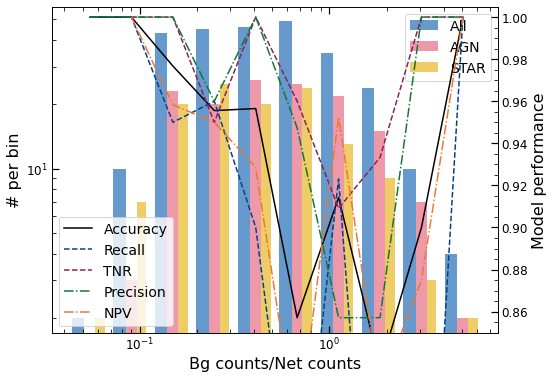

In [48]:
plot_model_perf(model_pl, test_loader, test_labels, test_bgratio,
                'Bg counts/Net counts')

## Evaluation of spectra

### No pseudolabelling

In [108]:
def plot_mean_spectra(model, data, labels, en_bins, pred_labels=None,
                      legend=None, loader=None):
    if legend is None:
        legend = ['True Negatives', 'True Positives', 'False negatives',
                  'False positives']
    if loader is None:
        loader = DataLoader(
            TensorDataset(torch.tensor(data,
                                       dtype=torch.float32).unsqueeze(1),
                          torch.tensor(labels, dtype=torch.long)),
            batch_size=64, shuffle=False)
    if pred_labels is None:
        pred_labels = evaluate_auto(model, loader, device)
    plt.figure()
    data = np.array(data)
    plt.xscale('log')
    plt.xlabel('Energy [keV]')
    plt.ylabel('Normalized counts/keV')
    print(np.mean(data[np.logical_and(labels==0, pred_labels==0)]))
    plt.plot(en_bins, np.mean(data[
        np.logical_and(labels==0, pred_labels==0)], axis=0).reshape(-1))
    plt.plot(en_bins, np.mean(data[
        np.logical_and(labels==1, pred_labels==1)], axis=0).reshape(-1))
    plt.plot(en_bins, np.mean(data[
        np.logical_and(labels==1, pred_labels==0)], axis=0).reshape(-1))
    plt.plot(en_bins, np.mean(data[
        np.logical_and(labels==0, pred_labels==1)], axis=0).reshape(-1))
    plt.legend(legend)

In [50]:
en_bins_min = fits.getdata(
    '../Data/XMM_responses/PN/epn_e2_bu23_sY9_v21.0.rmf', 2)['E_MIN'][96:2000]
en_bins_max = fits.getdata(
    '../Data/XMM_responses/PN/epn_e2_bu23_sY9_v21.0.rmf', 2)['E_MAX'][96:2000]

In [51]:
en_bins = np.linspace(0.5, 10.0, 380)

0.0026315793


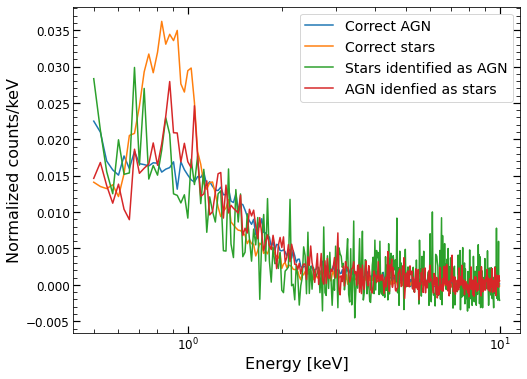

In [52]:
plot_mean_spectra(model, test_data, test_labels, en_bins, loader=test_loader,
                  legend=['Correct AGN',
                          'Correct stars',
                          'Stars identified as AGN',
                          'AGN idenfied as stars'])

### With Pseudo-labels

0.0026315786


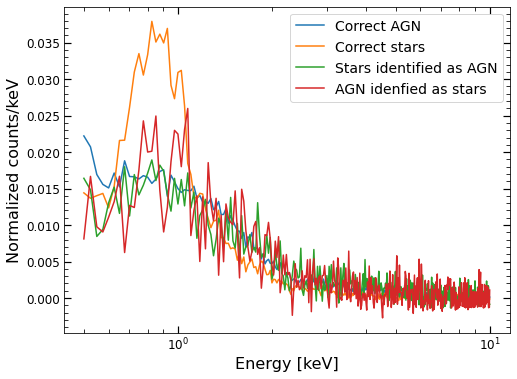

In [53]:
plot_mean_spectra(model_pl, test_data, test_labels, en_bins, loader=test_loader,
                  legend=['Correct AGN',
                          'Correct stars',
                          'Stars identified as AGN',
                          'AGN idenfied as stars'])

In [93]:
(test_labels == 0).sum()*0.06

16.08

## Performance on low counts

In [54]:
faintpn_args = np.where(np.logical_and(allpn_counts < 100, allpn_counts > 0))
faintpn_normspecs = allpn_normspec[faintpn_args]
faintpn_counts = allpn_counts[faintpn_args]
faintpn_bg_ratio = pn_bgcounts[faintpn_args]/faintpn_counts
faintpn_class = allpn_class[faintpn_args]

In [55]:
faintpn_class_refined = refine_labels(faintpn_class)

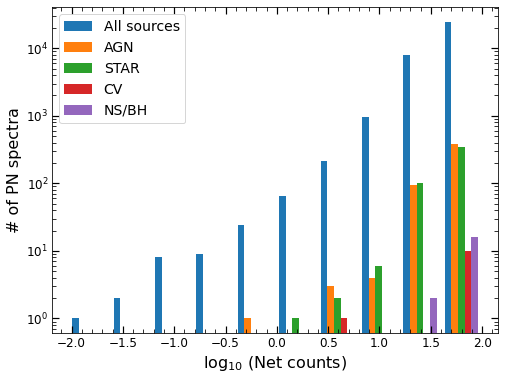

In [56]:
plt.hist([np.log10(faintpn_counts),
          np.log10(faintpn_counts[faintpn_class_refined=='AGN']),
          np.log10(faintpn_counts[faintpn_class_refined=='STAR']),
          np.log10(faintpn_counts[faintpn_class_refined=='CV']),
          np.log10(faintpn_counts[faintpn_class_refined=='NS/BH'])])
plt.yscale('log')
plt.xlabel(r'log$_{10}$ (Net counts)')
plt.ylabel('# of PN spectra')
plt.legend(['All sources', 'AGN', 'STAR', 'CV', 'NS/BH'])

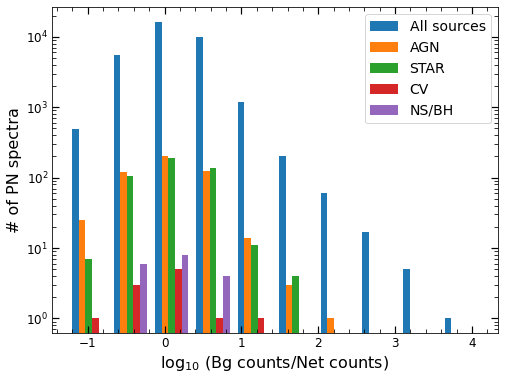

In [57]:
plt.hist([np.log10(faintpn_bg_ratio),
          np.log10(faintpn_bg_ratio[faintpn_class_refined=='AGN']),
          np.log10(faintpn_bg_ratio[faintpn_class_refined=='STAR']),
          np.log10(faintpn_bg_ratio[faintpn_class_refined=='CV']),
          np.log10(faintpn_bg_ratio[faintpn_class_refined=='NS/BH'])])
plt.yscale('log')
plt.xlabel(r'log$_{10}$ (Bg counts/Net counts)')
plt.ylabel('# of PN spectra')
plt.legend(['All sources', 'AGN', 'STAR', 'CV', 'NS/BH'])

In [58]:
faintpn_labelled_normspecs = faintpn_normspecs[
    np.where(np.logical_or(faintpn_class_refined == 'STAR',
                           faintpn_class_refined == 'AGN'))]
faintpn_labelled_counts = faintpn_counts[
    np.where(np.logical_or(faintpn_class_refined == 'STAR',
                           faintpn_class_refined == 'AGN'))]
faintpn_labelled_bgratio = faintpn_bg_ratio[
    np.where(np.logical_or(faintpn_class_refined == 'STAR',
                           faintpn_class_refined == 'AGN'))]
faintpn_labels = faintpn_class_refined[
    np.where(np.logical_or(faintpn_class_refined == 'STAR',
                           faintpn_class_refined == 'AGN'))]

In [59]:
faintpn_labels[faintpn_labels == 'STAR'] = 1
faintpn_labels[faintpn_labels == 'AGN'] = 0

In [60]:
faint_label_spectra = torch.tensor(faintpn_labelled_normspecs,
                                   dtype=torch.float32).unsqueeze(1)
faint_class_tensor = torch.tensor(faintpn_labels.astype(int), dtype=torch.long)

In [61]:
faint_dataset = TensorDataset(faint_label_spectra, faint_class_tensor)
faint_loader = DataLoader(faint_dataset, batch_size=64, shuffle=False)

### No pseudolabel

(0.7460148777895855, 0.6503067484662577, 0.8495575221238938, 0.8238341968911918, 0.6918918918918919)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in long_scalars
  
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == '__main__':


(array([ 0.48874191,  0.8317363 ,  1.41544084,  2.40878363,  4.09924485,
         6.97605552, 11.87178429, 20.20328849, 34.38176233, 58.51055295,
        99.57269711]),
 array([0.        ,        nan, 1.        , 0.33333333, 0.33333333,
        0.5       , 0.62068966, 0.60833333, 0.67045455, 0.83106796]),
 array([0.        ,        nan,        nan, 0.        , 0.        ,
        0.        , 0.33333333, 0.40983607, 0.53846154, 0.77857143]),
 array([       nan,        nan, 1.        , 1.        , 0.5       ,
        0.66666667, 0.82352941, 0.81355932, 0.79850746, 0.89361702]),
 array([       nan,        nan,        nan,        nan, 0.        ,
        0.        , 0.57142857, 0.69444444, 0.72164948, 0.89711934]),
 array([0.        ,        nan, 1.        , 0.33333333, 0.5       ,
        0.66666667, 0.63636364, 0.57142857, 0.64071856, 0.77205882]))

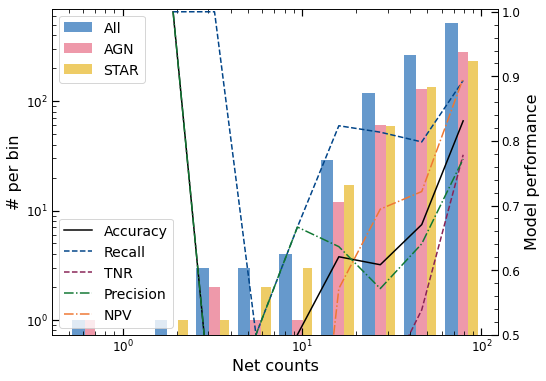

In [68]:
plot_model_perf(model, faint_loader, faintpn_labels.astype(int),
                faintpn_labelled_counts, 'Net counts')

### With pseudolabels

(0.7832093517534537, 0.852760736196319, 0.7079646017699115, 0.7595628415300546, 0.8163265306122449)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in long_scalars
  
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == '__main__':


(array([ 0.48874191,  0.8317363 ,  1.41544084,  2.40878363,  4.09924485,
         6.97605552, 11.87178429, 20.20328849, 34.38176233, 58.51055295,
        99.57269711]),
 array([0.        ,        nan, 1.        , 0.66666667, 0.66666667,
        0.25      , 0.75862069, 0.69166667, 0.71969697, 0.84466019]),
 array([0.        ,        nan,        nan, 0.5       , 1.        ,
        0.        , 0.91666667, 0.78688525, 0.81538462, 0.88928571]),
 array([       nan,        nan, 1.        , 1.        , 0.5       ,
        0.33333333, 0.64705882, 0.59322034, 0.62686567, 0.79148936]),
 array([       nan,        nan,        nan, 1.        , 0.5       ,
        0.        , 0.64705882, 0.66666667, 0.67948718, 0.83557047]),
 array([0.        ,        nan, 1.        , 0.5       , 1.        ,
        0.5       , 0.91666667, 0.72916667, 0.77777778, 0.85714286]))

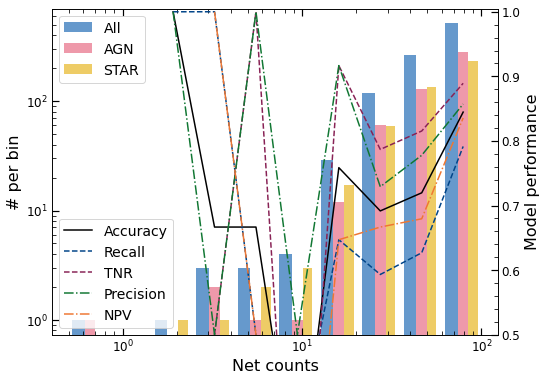

In [69]:
plot_model_perf(model_pl, faint_loader, faintpn_labels.astype(int),
                faintpn_labelled_counts, 'Net counts')

# With Autoencoders

## Latent space visualization

In [26]:
autoencoder_train = torch.load('train_data_atoencoder_best_mos.pt', weights_only=False)
autoencoder_test = torch.load('test_data_autoencoder_best_mos.pt', weights_only=False)
brightpn_latent = torch.load('Latent_mos_spectra.pt', weights_only=False)

In [72]:
brightpn_labelled_latent = brightpn_latent[
    np.logical_or(pn_class_refined=='STAR', pn_class_refined=='AGN')]
brightpn_classes = pn_class_refined[
    np.logical_or(pn_class_refined=='STAR', pn_class_refined=='AGN')]
brightpn_classes[brightpn_classes == 'STAR'] = 1
brightpn_classes[brightpn_classes == 'AGN'] = 0
brightpn_classes = brightpn_classes.astype(int)

In [220]:
agn_star_ids = np.where(
    np.logical_or(pn_class_refined=='STAR', pn_class_refined=='AGN'))[0]
allids = np.where(pn_class_refined != '')[0]

In [233]:
def get_tsne_plot(X, y_labels=None, label_ids=None):
    
    X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X[label_ids])

    #plt.figure(figsize=(7,6))
    #sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], color='gray', s=3, alpha=0.2)
    sns.scatterplot(
        x=X_tsne[:, 0], y=X_tsne[:,1],
        hue=y_labels, palette='tab10', s=20, edgecolor='k')
    plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
    plt.legend()
    plt.show()

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


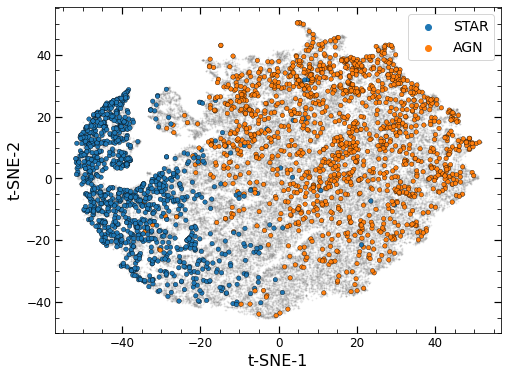

In [227]:
get_tsne_plot(brightpn_latent.detach().cpu().numpy(),
              pn_class_refined[agn_star_ids], label_ids=agn_star_ids)

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


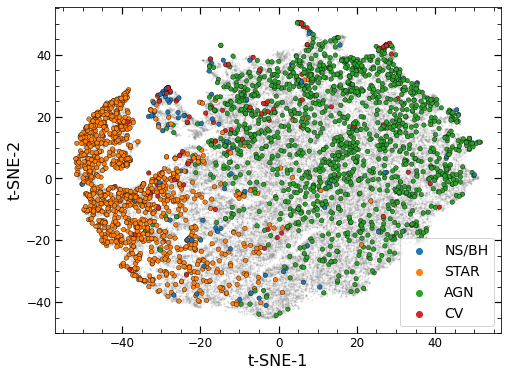

In [228]:
get_tsne_plot(brightpn_latent.detach().cpu().numpy(),
              pn_class_refined[allids], label_ids=allids)

In [223]:
pca = PCA(n_components=32, whiten=False, random_state=42)
pca.fit(pn_normspec)
spec_pca = pca.transform(pn_normspec)

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


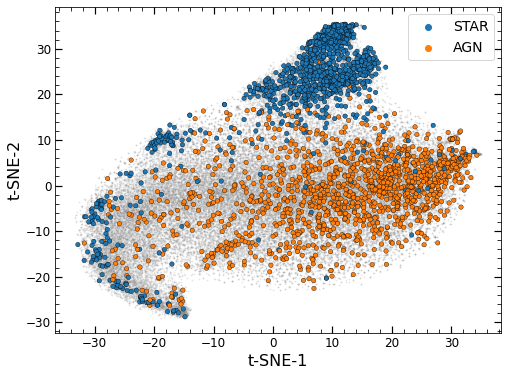

In [229]:
get_tsne_plot(spec_pca,
              pn_class_refined[agn_star_ids], label_ids=agn_star_ids)

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


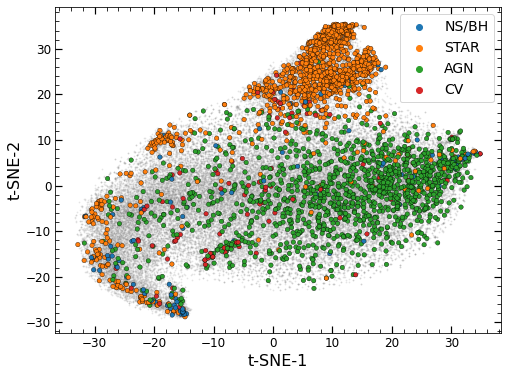

In [230]:
get_tsne_plot(spec_pca,
              pn_class_refined[allids], label_ids=allids)

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


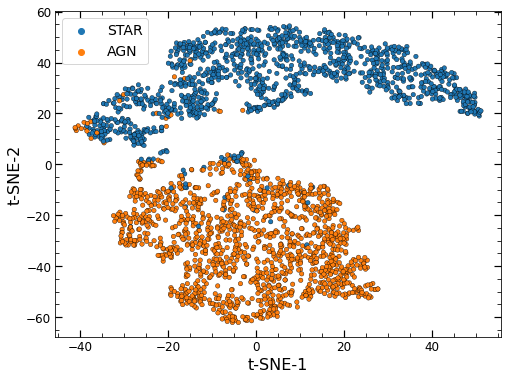

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


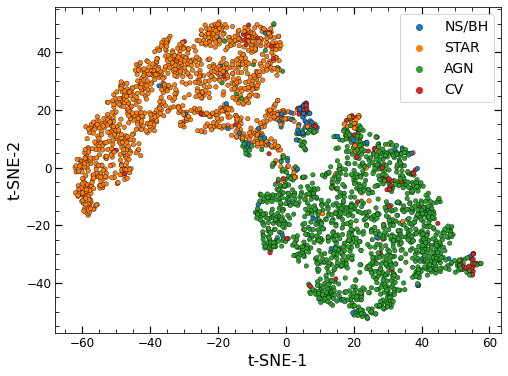

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


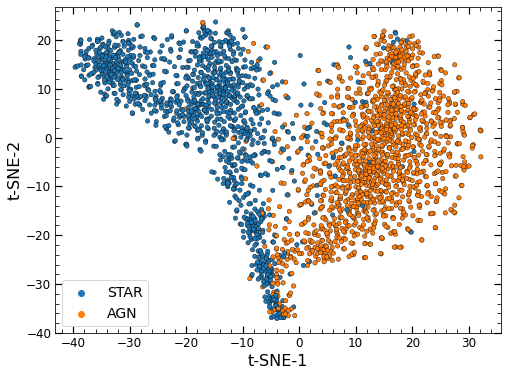

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


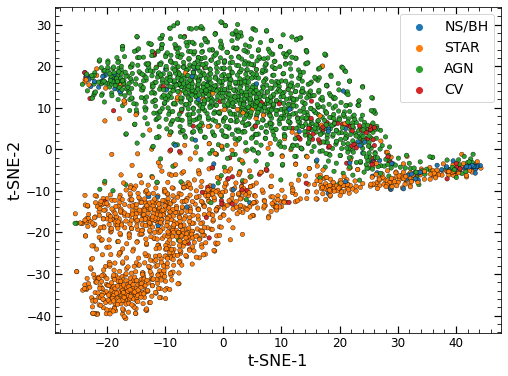

In [235]:
get_tsne_plot(brightpn_latent.detach().cpu().numpy(),
              pn_class_refined[agn_star_ids], label_ids=agn_star_ids)
get_tsne_plot(brightpn_latent.detach().cpu().numpy(),
              pn_class_refined[allids], label_ids=allids)
get_tsne_plot(spec_pca,
              pn_class_refined[agn_star_ids], label_ids=agn_star_ids)
get_tsne_plot(spec_pca,
              pn_class_refined[allids], label_ids=allids)

In [202]:
brightpn_labelled_latent = brightpn_latent[pn_class_refined != '']
brightpn_classes = pn_class_refined[pn_class_refined != '']
brightpn_classes[brightpn_classes == 'STAR'] = 1
brightpn_classes[brightpn_classes == 'AGN'] = 0
brightpn_classes[brightpn_classes == 'CV'] = 2
brightpn_classes[brightpn_classes == 'NS/BH'] = 3
brightpn_classes = brightpn_classes.astype(int)

In [203]:
np.max(brightpn_classes)

3

/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


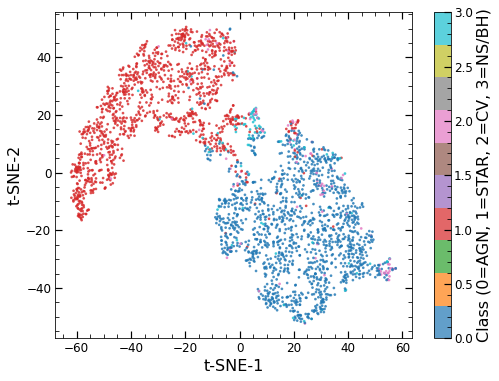

In [204]:
get_tsne_plot(brightpn_labelled_latent.detach().cpu().numpy(),
              brightpn_classes)

In [73]:
test_data_a, test_labels_a = autoencoder_test.tensors

In [74]:
test_labels_a

tensor([1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
        1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
        0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
        1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
        0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
        0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
        1, 0, 1, 0, 1])

In [75]:
test_counts_a = test_data_a[:, :, -1]
test_spec_a = test_data_a[:, :, :-1]

In [76]:
test_loader_a = DataLoader(
    TensorDataset(test_spec_a, test_labels_a), batch_size=64, shuffle=False)

In [27]:
class SemiSupervisedAE(nn.Module):
    def __init__(self, num_classes=2, latent_dim=32, drop=0.0, l_noise=0.05):
        super().__init__()

        # ---------- Encoder ----------
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=7, padding=3),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.MaxPool1d(2),

            nn.Conv1d(8, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(drop),
            nn.MaxPool1d(2),
        )

        # compute encoded feature size
        self._enc_out_dim = 16 * (380 // 4)  # assuming input length 380
        self.fc_enc = nn.Linear(self._enc_out_dim, latent_dim)
        self.latent_noise_std = l_noise

        # ---------- Decoder ----------
        self.fc_dec = nn.Linear(latent_dim, self._enc_out_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.ConvTranspose1d(8, 1, kernel_size=7, padding=3),
            nn.Softplus()  # ensures positive reconstructed counts
        )

        # ---------- Classifier ----------
        self.classifier = nn.Sequential(
            # nn.Linear(latent_dim, 64),
            # nn.ReLU(),
            nn.Linear(latent_dim, num_classes)
        )

    def forward(self, x):
        # x: (B, 1, 380)
        z = self.encoder(x)
        z = z.view(x.size(0), -1)
        z = self.fc_enc(z)
        if self.training and self.latent_noise_std > 0:
            dim_std = z.std(dim=0, unbiased=False,
                            keepdim=True).clamp(min=1e-3)
            z_decode = z + torch.randn_like(z)*self.latent_noise_std*dim_std
            z_class = z + torch.randn_like(z)*(self.latent_noise_std*4*dim_std)
            # print(torch.randn_like(z)*self.latent_noise_std*5*dim_std)
        else:
            z_decode = z
            z_class = z

        # Decode
        dec = self.fc_dec(z_decode)
        dec = dec.view(x.size(0), 16, 380 // 4)
        x_hat = self.decoder(dec)

        # Upsample back to 380 bins
        x_hat = nn.functional.interpolate(x_hat, size=380, mode="linear")

        # Classify
        # z = self.dropout_latent(z)
        logits = self.classifier(z_class)
        return x_hat, logits, z

In [28]:
auto_model = torch.load('autoencoder_mosmodels_noisy_best.pt', weights_only=False)[8]

In [29]:
auto_model

SemiSupervisedAE(
  (encoder): Sequential(
    (0): Conv1d(1, 8, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(8, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.0, inplace=False)
    (9): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_enc): Linear(in_features=1520, out_features=32, bias=True)
  (fc_dec): Linear(in_features=32, out_features=1520, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose1d(16, 8, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): ReLU()
    (2): ConvTranspose1d(8, 1, kernel_size=(7,), stride=(1,), padding=(3,))
    (3): Softplus(beta=1, threshold=20)

In [118]:
def evaluate_auto(model, loader, device):
    model.eval()
    all_preds = np.array([])
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            _, logits, _ = model(xb)
            preds = list(np.array(logits.argmax(dim=1)))
            all_preds = np.append(all_preds.copy(), preds)
            
    return all_preds

In [119]:
auto_preds = evaluate_auto(auto_model, test_loader_a, device)

(0.9368029739776952, 0.9444444444444444, 0.928, 0.9379310344827586, 0.9354838709677419)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: invalid value encountered in long_scalars
  
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in long_scalars
  if __name__ == '__main__':


(array([  100.08875438,   164.3605069 ,   269.90421049,   443.22254909,
          727.83684132,  1195.2155157 ,  1962.72027998,  3223.07637982,
         5292.76711312,  8691.5047652 , 14272.7336134 ]),
 array([0.91891892, 0.91954023, 0.94736842, 0.94117647, 1.        ,
        1.        , 1.        , 1.        ,        nan,        nan]),
 array([0.89583333, 0.97435897, 0.95454545, 0.94444444, 1.        ,
        1.        , 1.        ,        nan,        nan,        nan]),
 array([0.96153846, 0.875     , 0.9375    , 0.9375    , 1.        ,
        1.        , 1.        , 1.        ,        nan,        nan]),
 array([0.97727273, 0.86363636, 0.95454545, 0.94444444, 1.        ,
        1.        , 1.        ,        nan,        nan,        nan]),
 array([0.83333333, 0.97674419, 0.9375    , 0.9375    , 1.        ,
        1.        , 1.        , 1.        ,        nan,        nan]))

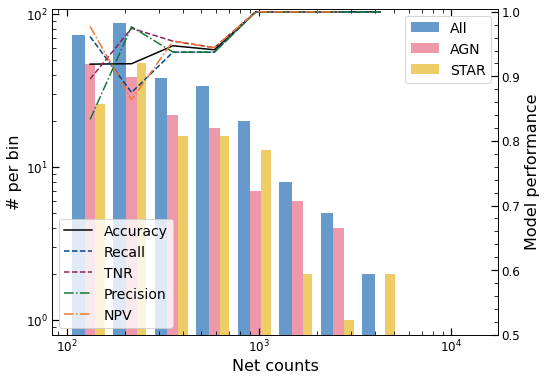

In [120]:
plot_model_perf(auto_model, test_loader_a, np.array(test_labels_a),
                np.array(test_counts_a).reshape(-1), 'Net counts')

In [294]:
pn_counts_32 = pn_counts.astype(np.float32)

In [299]:
np.where(np.logical_and(
    pn_counts_32 >= 155.086 - 0.0001,  pn_counts_32<155.086 + 0.0001))

(array([53636]),)

In [91]:
def get_bg_ratio_a(counts, bgratio, counts_a):
    bgratio_a = np.zeros_like(counts_a)
    for i, count in enumerate(counts_a):
        diff = np.abs(counts - count)
        print(i, np.min(diff))
        bgratio_a[i] = bgratio[np.argmin(diff)]
    return bgratio_a

In [92]:
pn_bgratio_a = get_bg_ratio_a(pn_counts, pn_bg_ratio, np.array(test_counts_a))

0 8.045585104810016e-07
1 3.450273311500496e-07
2 3.1836631933401804e-05
3 3.6573346733348444e-06
4 3.0386145510874485e-06
5 4.3340160686966556e-06
6 7.2242668807120936e-06
7 5.812098663682264e-06
8 1.8826211316991248e-05
9 6.259970689370675e-06
10 0.00022498768703371752
11 0.0002502674178685993
12 3.823142151304637e-06
13 2.055538942613566e-06
14 1.4810044888236007e-05
15 5.1205374802520964e-06
16 1.9910343780793482e-05
17 2.551263264649606e-06
18 2.3894305627436552e-05
19 3.089872109285352e-07
20 2.2456850956587004e-06
21 8.714824275557476e-07
22 6.277302730950396e-06
23 3.8071111845283667e-06
24 4.124906979541265e-06
25 7.891432233009255e-06
26 1.091881642878434e-05
27 1.0857747554382513e-06
28 2.443594212309108e-06
29 9.496247059814777e-07
30 3.5050777569267666e-07
31 8.823480328601363e-07
32 1.3100682281219633e-06
33 6.49700200483494e-06
34 1.6816299819311098e-06
35 1.1064195888366157e-06
36 7.207862040559121e-07
37 1.7718025446811225e-07
38 3.368448233231902e-06
39 4.047200150125

(0.9368029739776952, 0.9444444444444444, 0.928, 0.9379310344827586, 0.9354838709677419)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in long_scalars
  del sys.path[0]
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in long_scalars
  


(array([0.04110063, 0.06798623, 0.11245881, 0.18602274, 0.30770784,
        0.50899215, 0.84194478, 1.39269539, 2.30371455, 3.8106687 ,
        6.30338334]),
 array([1.        , 1.        , 1.        , 0.95555556, 0.97826087,
        0.85714286, 0.88571429, 0.91666667, 0.9       , 1.        ]),
 array([       nan, 1.        , 1.        , 0.9       , 0.96153846,
        0.92      , 0.86363636, 1.        , 1.        , 1.        ]),
 array([1.        , 1.        , 1.        , 1.        , 1.        ,
        0.79166667, 0.92307692, 0.77777778, 0.66666667, 1.        ]),
 array([       nan, 1.        , 1.        , 1.        , 1.        ,
        0.82142857, 0.95      , 0.88235294, 0.875     , 1.        ]),
 array([1.        , 1.        , 1.        , 0.92592593, 0.95238095,
        0.9047619 , 0.8       , 1.        , 1.        , 1.        ]))

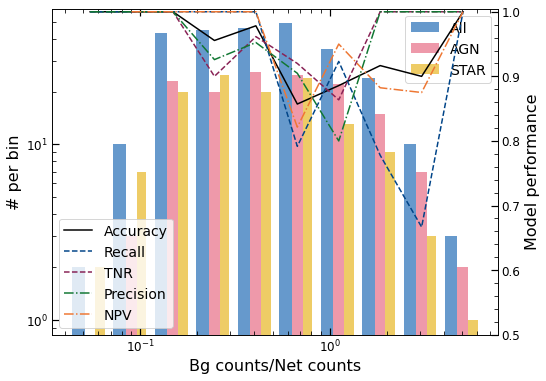

In [152]:
plot_model_perf(auto_model, test_loader_a, np.array(test_labels_a),
                pn_bgratio_a.reshape(-1), 'Bg counts/Net counts')

(0.7895855472901169, 0.7811860940695297, 0.7986725663716814, 0.8076109936575053, 0.7713675213675214)


/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in long_scalars
  del sys.path[0]
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: RuntimeWarning: invalid value encountered in long_scalars
  
/Users/pavanrh/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in long_scalars
  if sys.path[0] == '':


(array([ 0.48874191,  0.8317363 ,  1.41544084,  2.40878363,  4.09924485,
         6.97605552, 11.87178429, 20.20328849, 34.38176233, 58.51055295,
        99.57269711]),
 array([0.        ,        nan, 1.        , 1.        , 1.        ,
        0.5       , 0.62068966, 0.69166667, 0.73106061, 0.85242718]),
 array([0.        ,        nan,        nan, 1.        , 1.        ,
        0.        , 0.58333333, 0.68852459, 0.71538462, 0.84285714]),
 array([       nan,        nan, 1.        , 1.        , 1.        ,
        0.66666667, 0.64705882, 0.69491525, 0.74626866, 0.86382979]),
 array([       nan,        nan,        nan, 1.        , 1.        ,
        0.        , 0.53846154, 0.7       , 0.73228346, 0.88059701]),
 array([0.        ,        nan, 1.        , 1.        , 1.        ,
        0.66666667, 0.6875    , 0.68333333, 0.72992701, 0.82186235]))

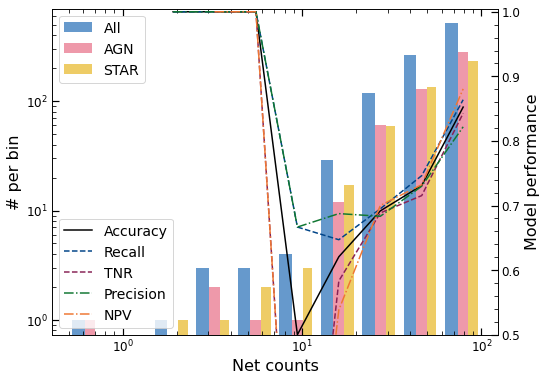

In [153]:
plot_model_perf(auto_model, faint_loader, faintpn_labels.astype(int),
                faintpn_labelled_counts, 'Net counts')

In [333]:
pn_bgratio_a

array([[ 1.6903963 ],
       [ 1.0205438 ],
       [ 0.73626834],
       [ 3.671676  ],
       [ 2.0319219 ],
       [ 0.7397474 ],
       [ 6.541899  ],
       [ 0.21202098],
       [ 0.22748713],
       [ 0.7228264 ],
       [ 1.2857264 ],
       [ 0.3369152 ],
       [ 0.2396367 ],
       [ 0.63389945],
       [ 1.219929  ],
       [ 1.8153373 ],
       [ 0.11620717],
       [ 0.46430835],
       [ 0.34300163],
       [ 0.28203475],
       [ 0.28252703],
       [ 1.0762196 ],
       [ 2.4399235 ],
       [ 0.45921955],
       [ 0.6059689 ],
       [ 0.31303722],
       [ 3.5540159 ],
       [ 9.844527  ],
       [11.134422  ],
       [ 3.468048  ],
       [ 0.6893452 ],
       [ 1.5238403 ],
       [ 3.4227686 ],
       [ 2.298058  ],
       [ 0.14580542],
       [ 0.1365655 ],
       [ 0.3089454 ],
       [ 0.10059889],
       [ 0.24138525],
       [ 1.4477977 ],
       [ 0.81387454],
       [ 8.258268  ],
       [ 0.25424314],
       [ 0.76651984],
       [ 0.666349  ],
       [ 0

In [98]:
len(pn_class_refined)

28026

0.002631579


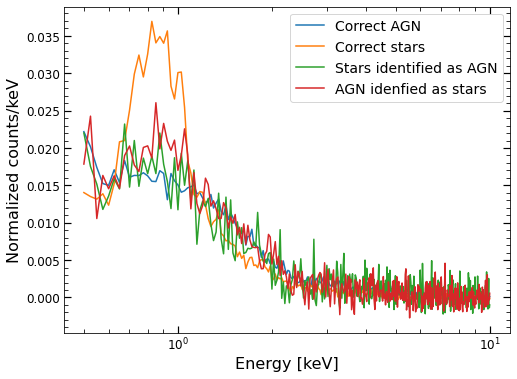

In [114]:
plot_mean_spectra(auto_model, test_spec_a, np.array(test_labels_a),
                  en_bins, loader=test_loader_a, pred_labels=auto_preds,
                  legend=['Correct AGN',
                          'Correct stars',
                          'Stars identified as AGN',
                          'AGN idenfied as stars'])

In [112]:
np.where(auto_preds == np.array(test_labels_a))

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  37,  38,  39,
         40,  41,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,
         54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
         67,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,
         81,  82,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
         95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 107, 108,
        109, 110, 111, 112, 113, 114, 115, 118, 119, 120, 121, 122, 123,
        124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136,
        137, 138, 139, 142, 144, 145, 146, 149, 150, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 176, 177, 178, 179, 180, 181, 182,
        184, 185, 186, 188, 189, 190, 191, 192, 193

In [113]:
auto_preds

array([1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0.,
       1., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
       1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1.,
       0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 0.,
       0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1.,
       1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 0.,
       1., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 0., 1., 0.,
       1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1.,
       0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.,
       0., 1., 0., 0., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1.,
       0., 0., 0., 1., 1.

In [30]:
unlabelled_args = np.where(pn_class_refined == '')
unlabelled_specdata = TensorDataset(torch.tensor(
    pn_normspec[unlabelled_args], dtype=torch.float32).unsqueeze(1))

In [31]:
unlabelled_loader = DataLoader(unlabelled_specdata, batch_size=64, shuffle=False)

In [32]:
def evaluate_conf(model, loader, device, threshold=0.9):
    model.eval()
    all_preds = np.array([])
    all_confs = np.array([])
    with torch.no_grad():
        for xb in loader:
            xb = xb[0].to(device)
            probs = torch.softmax(model(xb), dim=1)
            conf, preds = torch.max(probs, dim=1)
            
            all_preds = np.append(all_preds.copy(), np.array(preds))
            all_confs = np.append(all_confs.copy(), np.array(conf))
            
    return all_preds, all_confs

In [33]:
unlabeled_labels_conf = evaluate_conf(model_pl, unlabelled_loader, device)

/var/folders/v5/192l36gj409197xbd3ttmt6c0000gt/T/ipykernel_73181/484245407.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_preds = np.append(all_preds.copy(), np.array(preds))
/var/folders/v5/192l36gj409197xbd3ttmt6c0000gt/T/ipykernel_73181/484245407.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_confs = np.append(all_confs.copy(), np.array(conf))


In [34]:
num_stars = np.logical_and(unlabeled_labels_conf[0] == 1,
                           unlabeled_labels_conf[1] >= 0.9).sum()
num_agn = np.logical_and(unlabeled_labels_conf[0] == 0,
                           unlabeled_labels_conf[1] >= 0.9).sum()
print(num_stars, num_agn)

6696 18611


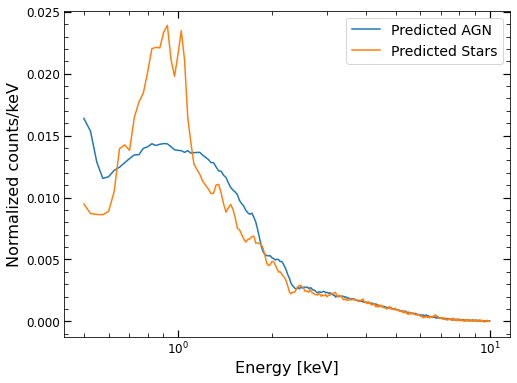

In [151]:
plt.figure()
data = pn_normspec[unlabelled_args]
plt.xscale('log')
plt.xlabel('Energy [keV]')
plt.ylabel('Normalized counts/keV')
plt.plot(en_bins, np.mean(data[
    np.logical_and(unlabeled_labels_conf_a[0] == 0,
                   unlabeled_labels_conf_a[1] >= 0.9)], axis=0).reshape(-1))
plt.plot(en_bins, np.mean(data[
    np.logical_and(unlabeled_labels_conf[0] == 1,
                   unlabeled_labels_conf[1] >= 0.9)], axis=0).reshape(-1))

plt.legend(['Predicted AGN', 'Predicted Stars'])

In [35]:
def evaluate_conf_auto(model_temp, loader, device, threshold=0.9):
    model_temp.eval()
    all_preds = np.array([])
    all_confs = np.array([])
    with torch.no_grad():
        for xb in loader:
            xb = xb[0].to(device)
            logits = model_temp(xb)[1]
            probs = torch.softmax(logits, dim=1)
            conf, preds = torch.max(probs, dim=1)
            
            all_preds = np.append(all_preds.copy(), np.array(preds))
            all_confs = np.append(all_confs.copy(), np.array(conf))
            
    return all_preds, all_confs

In [36]:
unlabeled_labels_conf_a = evaluate_conf_auto(auto_model, unlabelled_loader, device)

/var/folders/v5/192l36gj409197xbd3ttmt6c0000gt/T/ipykernel_73181/3006312691.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_preds = np.append(all_preds.copy(), np.array(preds))
/var/folders/v5/192l36gj409197xbd3ttmt6c0000gt/T/ipykernel_73181/3006312691.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_confs = np.append(all_confs.copy(), np.array(conf))


In [37]:
num_stars = np.logical_and(unlabeled_labels_conf_a[0] == 1,
                           unlabeled_labels_conf_a[1] >= 0.9).sum()
num_agn = np.logical_and(unlabeled_labels_conf_a[0] == 0,
                           unlabeled_labels_conf_a[1] >= 0.9).sum()
print(num_stars, num_agn)

6126 16372


NameError: name 'en_bins' is not defined

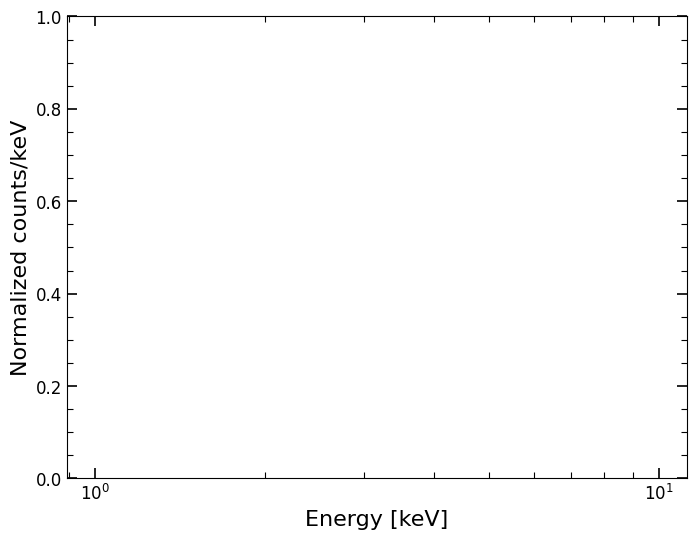

In [38]:
plt.figure()
data = pn_normspec[unlabelled_args]
plt.xscale('log')
plt.xlabel('Energy [keV]')
plt.ylabel('Normalized counts/keV')
plt.plot(en_bins, np.mean(data[
    np.logical_and(unlabeled_labels_conf[0] == 0,
                   unlabeled_labels_conf[1] >= 0.9)], axis=0).reshape(-1))
plt.plot(en_bins, np.mean(data[
    np.logical_and(unlabeled_labels_conf[0] == 1,
                   unlabeled_labels_conf[1] >= 0.9)], axis=0).reshape(-1))

plt.legend(['Predicted AGN', 'Predicted Stars'])

In [39]:
both_stars = np.logical_and(unlabeled_labels_conf[0] == 1,
                            unlabeled_labels_conf_a[0] == 1).sum()
both_agn = np.logical_and(unlabeled_labels_conf[0] == 0,
                            unlabeled_labels_conf_a[0] == 0).sum()
print(both_stars, both_agn)
print(len(unlabeled_labels_conf[0]))

6433 17661
26523


In [40]:
both_stars_90 = np.logical_and(
    np.logical_and(unlabeled_labels_conf[0] == 1,
                   unlabeled_labels_conf[1] >= 0.9),
    np.logical_and(unlabeled_labels_conf_a[0] == 1,
                   unlabeled_labels_conf_a[1] >= 0.9)).sum()
both_agn_90 =  np.logical_and(
    np.logical_and(unlabeled_labels_conf[0] == 0,
                   unlabeled_labels_conf[1] >= 0.9),
    np.logical_and(unlabeled_labels_conf_a[0] == 0,
                   unlabeled_labels_conf_a[1] >= 0.9)).sum()
print(both_stars_90, both_agn_90)
print(len(unlabeled_labels_conf[0]))

5296 15808
26523


In [132]:
test_preds, test_conf = evaluate_conf(model_pl, test_loader, device)

In [133]:
get_stats(test_preds, test_labels, test_conf)

(0.937984496124031,
 0.9444444444444444,
 0.848,
 0.9251700680272109,
 0.954954954954955)

In [134]:
test_preds_a, test_conf_a = evaluate_conf_auto(auto_model, test_loader_a, device)

In [135]:
get_stats(test_preds_a, test_labels_a, test_conf_a)

(tensor(0.9631),
 tensor(0.8750),
 tensor(0.8720),
 tensor(0.9545),
 tensor(0.9732))

In [137]:
len(unlabelled_specdata)

26523

In [144]:
flux_2 = np.sum(pn_normspec[:, :20]*en_bins[:20], axis=1)
flux_3 = np.sum(pn_normspec[:, 20:60]*en_bins[20:60], axis=1)
flux_4 = np.sum(pn_normspec[:, 60:160]*en_bins[60:160], axis=1)

In [145]:
print(len(np.where(flux_2 < 0)[0]))
print(len(np.where(flux_3 < 0)[0]))
print(len(np.where(flux_4 < 0)[0]))

546
109
493


In [146]:
flux_2[flux_2 < 0] = np.nan
flux_3[flux_3 < 0] = np.nan
flux_4[flux_4 < 0] = np.nan

In [147]:
hr_23 = (flux_3 - flux_2)/(flux_3 + flux_2)
hr_34 = (flux_4 - flux_3)/(flux_4 + flux_3)

In [148]:
un_agn_mask = np.logical_and(unlabeled_labels_conf[0] == 0,
                           unlabeled_labels_conf[1] >= 0.9)
un_star_mask = np.logical_and(unlabeled_labels_conf[0] == 1,
                           unlabeled_labels_conf[1] >= 0.9)

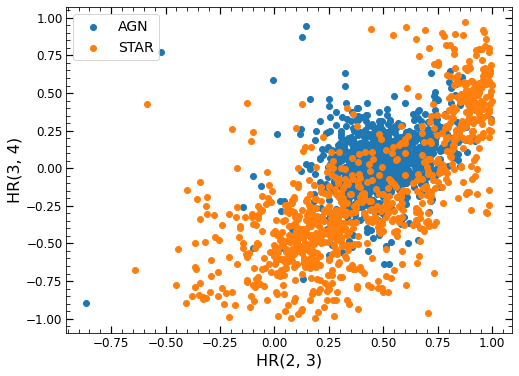

In [149]:
plt.scatter(hr_23[unlabelled_args][un_agn_mask][:1000],
            hr_34[unlabelled_args][un_agn_mask][:1000], label='AGN')
plt.scatter(hr_23[unlabelled_args][un_star_mask][:1000],
            hr_34[unlabelled_args][un_star_mask][:1000], label='STAR')
plt.xlabel('HR(2, 3)')
plt.ylabel('HR(3, 4)')
plt.legend()
plt.show()